# MMLU Evaluation on Google Colab with CUDA Profiling

This notebook evaluates language models (1B-14B) on the MMLU benchmark using CUDA profiling.

**Models tested:**

Small models (1B-2B, no quantization):
- OLMo 2 1B Instruct
- Llama 3.2 1B Instruct
- Gemma 2 2B Instruct

Medium models (12B-14B, 4-bit quantization):
- Qwen 2.5 14B Instruct
- OLMo 2 13B Instruct
- Llama 3.1 Nemotron Nano 12B Instruct v2

**Features:**
- Adaptive quantization (4-bit for 12B+, FP16 for 1B-2B)
- CUDA profiling with torch.cuda.Event()
- Comprehensive timing and memory metrics
- 10 MMLU subjects (1,336 questions total)
- Compatible with Colab VSCode extension

**Total runtime**: ~2-3 hours for all 6 models on T4 GPU

## GPU Verification

⚠️ **IMPORTANT**: Verify you're using a GPU runtime (not CPU):
1. Runtime → Change runtime type → GPU (T4 or A100)
2. Run the cell below to check GPU availability

In [1]:
# Install dependencies
!pip install -q transformers datasets accelerate bitsandbytes tqdm

# Check GPU availability
import torch

print("="*70)
print("GPU CHECK")
print("="*70)
print(f"GPU Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"CUDA Version: {torch.version.cuda}")
    print("✓ Ready to run!")
else:
    print("⚠️  WARNING: No GPU detected!")
    print("   Go to: Runtime → Change runtime type → GPU")
print("="*70)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 27.0 MB/s eta 0:00:0000:0100:01m
GPU CHECK
GPU Available: True
GPU Name: NVIDIA A100-SXM4-40GB
GPU Memory: 42.41 GB
CUDA Version: 12.8
✓ Ready to run!


In [2]:
# Imports
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from datasets import load_dataset
from huggingface_hub import login
import json
from tqdm.auto import tqdm
import os
from datetime import datetime
import sys
import platform
import time
import resource
import gc
import subprocess
from contextlib import contextmanager
from getpass import getpass
import glob

print("✓ All imports successful")

✓ All imports successful


## Configuration

Set up models to test, MMLU subjects, and Hugging Face authentication.

In [109]:
# Multi-model evaluation
MODELS_TO_TEST = [
    # Small models (1B-2B) - no quantization needed
    # "allenai/OLMo-2-0425-1B-Instruct",
    # "meta-llama/Llama-3.2-1B-Instruct",
    # "google/gemma-2-2b-it",

    # Medium models (12B-14B) - 4-bit quantization required
    "Qwen/Qwen2.5-14B-Instruct",
    "allenai/OLMo-2-1124-13B-Instruct",
    "allenai/Olmo-3-7B-Think"
]

# ── Execution flags ────────────────────────────────────────────────────────────
USE_GPU  = True   # Set to False to force CPU execution (for timing comparison)
USE_4BIT = False   # 4-bit NF4 for medium models (CUDA only, ~7-8 GB)
USE_8BIT = False  # 8-bit (CUDA only, more accurate; overrides USE_4BIT when True)

MAX_NEW_TOKENS = 1

# Verbose mode - print each question, answer, and correctness
VERBOSE = False

# MMLU Subjects to test (10 subjects for comprehensive evaluation)
MMLU_SUBJECTS = [
    "astronomy", "business_ethics",
    "clinical_knowledge", "college_biology", "college_chemistry",
    "college_computer_science", "college_mathematics", "college_medicine",
    "college_physics", "computer_security"
]

# MMLU_SUBJECTS = [
#     "astronomy"
# ]

# ── Summary ────────────────────────────────────────────────────────────────────
print(f"✓ Configuration loaded")
print(f"  Models to test : {len(MODELS_TO_TEST)}")
print(f"  MMLU subjects  : {len(MMLU_SUBJECTS)}")
print(f"  USE_GPU        : {USE_GPU}")
print(f"  USE_4BIT       : {USE_4BIT}")
print(f"  USE_8BIT       : {USE_8BIT}  {'(overrides 4-bit)' if USE_8BIT else ''}")
print(f"  VERBOSE        : {VERBOSE}")


✓ Configuration loaded
  Models to test : 3
  MMLU subjects  : 10
  USE_GPU        : True
  USE_4BIT       : False
  USE_8BIT       : False  
  VERBOSE        : False


In [91]:
# Hugging Face Authentication
# Option 1: Use Colab secrets (recommended)
# Go to: Tools → Secrets → Add HF_TOKEN
try:
    from google.colab import userdata
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
    print("✓ Logged in via Colab secrets")
except:
    # Option 2: Manual entry
    hf_token = getpass("Enter your Hugging Face token: ")
    login(token=hf_token)
    print("✓ Logged in manually")

✓ Logged in manually


## CUDA Profiling Classes

Replace Apple Silicon PowerMetrics with CUDA profiling using `torch.cuda.Event()` and `nvidia-smi`.

In [92]:
class EvaluationTimer:
    """Robust timing for ML model evaluation with CUDA support"""

    def __init__(self, device):
        self.device = device
        self.is_cuda = (str(device).startswith("cuda"))
        self.phase_times = {}
        self.inference_times = []  # Per-question inference times

    def get_snapshot(self):
        """Capture current timing and resource state"""
        usage = resource.getrusage(resource.RUSAGE_SELF)
        return {
            'wall': time.perf_counter(),
            'user_cpu': usage.ru_utime,
            'sys_cpu': usage.ru_stime
        }

    def calculate_diff(self, start, end):
        """Calculate elapsed times from snapshots"""
        wall_time = end['wall'] - start['wall']
        user_cpu = end['user_cpu'] - start['user_cpu']
        sys_cpu = end['sys_cpu'] - start['sys_cpu']
        total_cpu = user_cpu + sys_cpu

        return {
            'wall_time': wall_time,
            'user_cpu_time': user_cpu,
            'system_cpu_time': sys_cpu,
            'total_cpu_time': total_cpu,
            'cpu_utilization': (total_cpu / wall_time * 100) if wall_time > 0 else 0
        }

    @contextmanager
    def phase(self, name):
        """Context manager for timing a phase (e.g., model loading)"""
        if self.is_cuda:
            torch.cuda.synchronize()

        start = self.get_snapshot()
        try:
            yield
        finally:
            if self.is_cuda:
                torch.cuda.synchronize()
            end = self.get_snapshot()
            self.phase_times[name] = self.calculate_diff(start, end)

    def time_inference(self, func, *args, **kwargs):
        """Time a single inference with CUDA events"""
        if self.is_cuda:
            # Use CUDA events for accurate timing
            start = torch.cuda.Event(enable_timing=True)
            end = torch.cuda.Event(enable_timing=True)

            torch.cuda.synchronize()
            start.record()

            result = func(*args, **kwargs)

            end.record()
            torch.cuda.synchronize()

            elapsed_sec = start.elapsed_time(end) / 1000.0  # ms to sec
            self.inference_times.append(elapsed_sec)
        else:
            # CPU fallback
            start_time = time.perf_counter()
            result = func(*args, **kwargs)
            elapsed_sec = time.perf_counter() - start_time
            self.inference_times.append(elapsed_sec)

        return result

    def get_summary(self):
        """Get complete timing summary with statistics"""
        import statistics

        summary = {'phases': self.phase_times}

        if self.inference_times:
            summary['inference'] = {
                'count': len(self.inference_times),
                'total': sum(self.inference_times),   # total GPU compute seconds
                'mean': statistics.mean(self.inference_times),
                'median': statistics.median(self.inference_times),
                'min': min(self.inference_times),
                'max': max(self.inference_times),
                'stdev': statistics.stdev(self.inference_times) if len(self.inference_times) > 1 else 0
            }

            # Add percentiles if we have enough samples
            if len(self.inference_times) >= 10:
                import math
                sorted_times = sorted(self.inference_times)
                p95_idx = max(0, math.ceil(len(sorted_times) * 0.95) - 1)
                p99_idx = max(0, math.ceil(len(sorted_times) * 0.99) - 1)
                summary['inference']['p95'] = sorted_times[p95_idx]
                summary['inference']['p99'] = sorted_times[p99_idx]

        return summary


class CUDAMetricsMonitor:
    """Monitor GPU metrics using CUDA APIs and nvidia-smi"""

    def __init__(self, device):
        self.device = device
        self.start_time = None
        self.end_time = None
        self.memory_snapshots = []
        self.gpu_util_samples = []

    def start(self):
        """Start monitoring"""
        self.start_time = time.perf_counter()

        # Record initial memory state
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()
            self.memory_snapshots.append({
                'timestamp': self.start_time,
                'allocated': torch.cuda.memory_allocated() / 1e9,  # GB
                'reserved': torch.cuda.memory_reserved() / 1e9
            })

            # Get GPU utilization from nvidia-smi
            util = self._get_gpu_utilization()
            if util is not None:
                self.gpu_util_samples.append(util)

    def stop(self):
        """Stop monitoring and return summary"""
        self.end_time = time.perf_counter()

        if torch.cuda.is_available():
            # Final memory snapshot
            self.memory_snapshots.append({
                'timestamp': self.end_time,
                'allocated': torch.cuda.memory_allocated() / 1e9,
                'reserved': torch.cuda.memory_reserved() / 1e9,
                'peak': torch.cuda.max_memory_allocated() / 1e9
            })

            # Final GPU utilization
            util = self._get_gpu_utilization()
            if util is not None:
                self.gpu_util_samples.append(util)

        return self._summarize()

    def _get_gpu_utilization(self):
        """Get current GPU utilization from nvidia-smi"""
        try:
            result = subprocess.run(
                ['nvidia-smi', '--query-gpu=utilization.gpu,memory.used,memory.total',
                 '--format=csv,nounits,noheader'],
                capture_output=True, text=True, timeout=5
            )
            gpu_util, mem_used, mem_total = result.stdout.strip().split(', ')
            return {
                'gpu_utilization': float(gpu_util),
                'memory_used_mb': float(mem_used),
                'memory_total_mb': float(mem_total)
            }
        except:
            return None

    def _summarize(self):
        """Calculate summary statistics"""
        import statistics

        duration = self.end_time - self.start_time

        summary = {
            'evaluation_duration_sec': duration
        }

        # GPU utilization summary
        if self.gpu_util_samples:
            utils = [s['gpu_utilization'] for s in self.gpu_util_samples]
            summary['gpu_utilization'] = {
                'mean': statistics.mean(utils),
                'min': min(utils),
                'max': max(utils)
            }

        # Memory summary
        if len(self.memory_snapshots) >= 2:
            peak_mem = self.memory_snapshots[-1].get('peak', 0)
            summary['gpu_memory_gb'] = {
                'start_allocated': self.memory_snapshots[0]['allocated'],
                'end_allocated': self.memory_snapshots[-1]['allocated'],
                'peak_allocated': peak_mem
            }

        # Approximate GPU cycles (if we can get frequency from nvidia-smi)
        if torch.cuda.is_available() and 'gpu_utilization' in summary:
            try:
                # Try to get GPU frequency from nvidia-smi
                result = subprocess.run(
                    ['nvidia-smi', '--query-gpu=clocks.current.graphics',
                     '--format=csv,nounits,noheader'],
                    capture_output=True, text=True, timeout=5
                )
                gpu_freq_mhz = float(result.stdout.strip())

                # Estimate active time from mean utilization
                mean_util = summary['gpu_utilization']['mean'] / 100.0
                gpu_active_time = duration * mean_util
                gpu_cycles_approx = gpu_freq_mhz * 1e6 * gpu_active_time

                summary['gpu_cycles'] = {
                    'total_approx': gpu_cycles_approx,
                    'gpu_freq_mhz': gpu_freq_mhz,
                    'note': 'Approximate - calculated from nvidia-smi clock rate and utilization'
                }
            except Exception:
                # GPU frequency not available, skip cycles calculation
                pass

        return summary


print("✓ CUDA profiling classes loaded")


✓ CUDA profiling classes loaded


## Device Detection and Environment Check

In [93]:
def detect_device():
    """Detect the best available device (CUDA or CPU)"""
    if not USE_GPU:
        return "cpu"

    if torch.cuda.is_available():
        return "cuda"

    return "cpu"


def check_environment():
    """Check environment and dependencies"""
    print("="*70)
    print("Environment Check")
    print("="*70)

    # Check if in Colab
    try:
        import google.colab
        print("✓ Running in Google Colab")
        in_colab = True
    except:
        print("✓ Running locally (not in Colab)")
        in_colab = False

    # Check system info
    print(f"✓ Platform: {platform.system()} ({platform.machine()})")

    # Detect and set device
    device = detect_device()

    # Check device
    if device == "cuda":
        gpu_name = torch.cuda.get_device_name(0)
        gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"✓ GPU Available: {gpu_name}")
        print(f"✓ GPU Memory: {gpu_memory:.2f} GB")
    else:
        print("⚠️  No GPU detected - running on CPU")

    # Print configuration
    print("\n" + "="*70)
    print("Configuration")
    print("="*70)
    print(f"Models: {len(MODELS_TO_TEST)} models to evaluate")
    for i, model in enumerate(MODELS_TO_TEST, 1):
        # Check if medium model
        is_medium = any(m in model for m in ["Qwen2.5-14B", "OLMo-2-1124-13B", "Nemotron-Nano-12B"])
        if is_medium and USE_8BIT:
            quant_str = " (8-bit)"
        elif is_medium and USE_4BIT:
            quant_str = " (4-bit NF4)"
        else:
            quant_str = " (FP16)" if device == "cuda" else " (FP32)"
        print(f"  {i}. {model}{quant_str}")
    print(f"Device: {device}")
    print(f"Quantization: {'8-bit' if USE_8BIT else '4-bit NF4' if USE_4BIT else 'none'}")
    print(f"Number of subjects: {len(MMLU_SUBJECTS)}")

    print("="*70 + "\n")
    return in_colab, device


print("✓ Environment functions loaded")


✓ Environment functions loaded


## Model Loading with Conditional Quantization

In [94]:
def get_quantization_config(model_name):
    """Return quantization config based on model size and active flags"""
    # Check if this is a medium model (12B+)
    medium_models = ["Qwen2.5-14B", "OLMo-2-1124-13B", "Nemotron-Nano-12B"]
    is_medium = any(m in model_name for m in medium_models)

    # 8-bit path (higher accuracy than 4-bit, requires more VRAM)
    if USE_8BIT:
        config = BitsAndBytesConfig(load_in_8bit=True)
        print("Using 8-bit quantization")
        print("Expected memory usage: ~10-12 GB")
        return config

    # 4-bit path (default for medium models)
    if is_medium and USE_4BIT:
        config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4"
        )
        print("Using 4-bit quantization (NF4 + double quant)")
        print("Expected memory usage: ~7-8 GB")
        return config

    # No quantization (small models, or GPU disabled)
    if is_medium:
        print("Using FP16 for medium model (no quantization — may require >16 GB VRAM)")
    else:
        print("Using FP16 (no quantization)")
    print("Expected memory usage: ~2.5-5 GB")
    return None


def load_model_and_tokenizer(device, model_name):
    """Load model with optional quantization"""
    # Force garbage collection before loading new model
    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()

    print(f"\nLoading model {model_name}...")
    print(f"Device: {device}")

    try:
        # Load tokenizer
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        print("✓ Tokenizer loaded")

        # Get quantization config
        quant_config = get_quantization_config(model_name)

        # Load model
        print("Loading model (this may take 2-3 minutes)...")

        if quant_config is not None:
            # Quantized model loading (medium models)
            model = AutoModelForCausalLM.from_pretrained(
                model_name,
                quantization_config=quant_config,
                device_map="auto",
                low_cpu_mem_usage=True
            )
        else:
            # Non-quantized model loading (small models)
            if device == "cuda":
                model = AutoModelForCausalLM.from_pretrained(
                    model_name,
                    torch_dtype=torch.float16,
                    device_map="auto",
                    low_cpu_mem_usage=True
                )
            else:  # CPU
                model = AutoModelForCausalLM.from_pretrained(
                    model_name,
                    torch_dtype=torch.float32,
                    low_cpu_mem_usage=True
                )
                model = model.to(device)

        model.eval()

        # Print model info
        print("✓ Model loaded successfully!")
        print(f"  Model device: {next(model.parameters()).device}")
        print(f"  Model dtype: {next(model.parameters()).dtype}")

        # Check memory usage
        if torch.cuda.is_available():
            memory_allocated = torch.cuda.memory_allocated(0) / 1e9
            memory_reserved = torch.cuda.memory_reserved(0) / 1e9
            print(f"  GPU Memory: {memory_allocated:.2f} GB allocated, {memory_reserved:.2f} GB reserved")

        return model, tokenizer

    except Exception as e:
        print(f"\n❌ Error loading model: {e}")
        print("\nPossible causes:")
        print("1. No Hugging Face token - Login required")
        print("2. Model license not accepted - Visit model page on HF")
        print("3. Out of memory - Try restarting runtime")
        raise


print("✓ Model loading functions defined")


✓ Model loading functions defined


## MMLU Evaluation Functions

In [95]:
def format_mmlu_prompt(question, choices):
    """Format MMLU question as multiple choice"""
    choice_labels = ["A", "B", "C", "D"]
    prompt = f"{question}\n\n"
    for label, choice in zip(choice_labels, choices):
        prompt += f"{label}. {choice}\n"
    prompt += "\nAnswer:"
    return prompt


def get_model_prediction(model, tokenizer, prompt, timer=None):
    """Get model's prediction with optional timing"""
    # Prepare inputs (not part of timed inference)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    def _inference():
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                pad_token_id=tokenizer.eos_token_id,
                do_sample=False,
                temperature=1.0
            )
        return outputs

    # Use timer if provided (for per-question timing)
    if timer:
        outputs = timer.time_inference(_inference)
    else:
        outputs = _inference()

    # Decode output
    generated_text = tokenizer.decode(
        outputs[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    )

    # Extract answer
    answer = generated_text.strip()[:1].upper()
    if answer not in ["A", "B", "C", "D"]:
        for char in generated_text.upper():
            if char in ["A", "B", "C", "D"]:
                answer = char
                break
        else:
            answer = "A"

    # Clear tensors to free memory
    del inputs, outputs

    return answer


def evaluate_subject(model, tokenizer, subject, timer=None, verbose=False):
    """Evaluate model on a specific MMLU subject with optional timing"""
    print(f"\n{'='*70}")
    print(f"Evaluating subject: {subject}")
    print(f"{'='*70}")

    try:
        dataset = load_dataset("cais/mmlu", subject, split="test")
    except Exception as e:
        print(f"❌ Error loading subject {subject}: {e}")
        return None

    correct = 0
    total = 0
    question_details = []  # Store per-question results

    for example in tqdm(dataset, desc=f"Testing {subject}", leave=True):
        question = example["question"]
        choices = example["choices"]
        correct_answer_idx = example["answer"]
        correct_answer = ["A", "B", "C", "D"][correct_answer_idx]

        prompt = format_mmlu_prompt(question, choices)
        predicted_answer = get_model_prediction(model, tokenizer, prompt, timer=timer)

        is_correct = predicted_answer == correct_answer
        if is_correct:
            correct += 1
        total += 1

        # Store per-question details
        question_details.append({
            "question": question,
            "choices": {
                "A": choices[0],
                "B": choices[1],
                "C": choices[2],
                "D": choices[3]
            },
            "predicted_answer": predicted_answer,
            "correct_answer": correct_answer,
            "is_correct": is_correct
        })

        # Verbose output
        if verbose:
            status = "✓" if is_correct else "✗"
            print(f"\n{status} Q{total}: {question}")
            print(f"   Choices: {', '.join([f'{lbl}={ch}' for lbl, ch in zip(['A','B','C','D'], choices)])}")
            print(f"   Model answer: {predicted_answer} | Correct: {correct_answer}")

    accuracy = (correct / total * 100) if total > 0 else 0
    print(f"✓ Result: {correct}/{total} correct = {accuracy:.2f}%")

    # Clear dataset from memory
    del dataset
    gc.collect()

    # Clear CUDA cache after each subject to prevent memory buildup
    if str(model.device).startswith("cuda"):
        torch.cuda.empty_cache()

    return {
        "subject": subject,
        "correct": correct,
        "total": total,
        "accuracy": accuracy,
        "questions": question_details
    }


print("✓ MMLU evaluation functions defined")

✓ MMLU evaluation functions defined


## Results Display and Save Functions

In [96]:
def print_comparative_summary(all_model_results, device):
    """Print comparison of all models with detailed timing breakdown"""
    print("\n" + "="*70)
    print("COMPARATIVE EVALUATION SUMMARY")
    print("="*70)
    print(f"Device: {device.upper()}")
    print(f"Subjects tested: {len(MMLU_SUBJECTS)}")
    print(f"Verbose mode: {'ON' if VERBOSE else 'OFF'}")
    print("="*70)

    for model_name, data in all_model_results.items():
        timing = data['timing']

        print(f"\n{'─'*70}")
        print(f"Model: {model_name}")
        print(f"{'─'*70}")

        # Accuracy
        print(f"Accuracy: {data['accuracy']:.2f}% ({data['total_correct']}/{data['total_questions']})")

        # Phase timing breakdown
        print(f"\nPhase Timing:")
        for phase_name, phase_data in timing['phases'].items():
            print(f"  {phase_name.replace('_', ' ').title()}:")
            print(f"    Wall time:    {phase_data['wall_time']:7.2f}s  ({phase_data['wall_time']/60:.2f} min)")
            print(f"    User CPU:     {phase_data['user_cpu_time']:7.2f}s")
            print(f"    System CPU:   {phase_data['system_cpu_time']:7.2f}s")
            print(f"    Total CPU:    {phase_data['total_cpu_time']:7.2f}s")
            print(f"    CPU usage:    {phase_data['cpu_utilization']:7.1f}%")

        # CUDA metrics if available
        if 'cuda_metrics' in timing:
            cm = timing['cuda_metrics']
            print(f"\n  CUDA GPU Metrics:")

            if 'gpu_utilization' in cm:
                s = cm['gpu_utilization']
                print(f"    GPU Util:     {s['mean']:7.1f}% (avg)  {s['max']:7.1f}% (peak)")

            if 'gpu_memory_gb' in cm:
                s = cm['gpu_memory_gb']
                print(f"    GPU Memory:   {s['peak_allocated']:7.2f} GB (peak)")

            if 'gpu_cycles' in cm:
                s = cm['gpu_cycles']
                print(f"    GPU Cycles:   {s['total_approx']/1e9:7.2f} B (approx)")
                print(f"    GPU Freq:     {s['gpu_freq_mhz']:7.0f} MHz")

        # Per-question inference statistics
        if 'inference' in timing:
            inf = timing['inference']
            print(f"\nPer-Question Inference Stats ({inf['count']} questions):")
            print(f"  Mean:         {inf['mean']*1000:7.2f}ms")
            print(f"  Median:       {inf['median']*1000:7.2f}ms")
            print(f"  Min:          {inf['min']*1000:7.2f}ms")
            print(f"  Max:          {inf['max']*1000:7.2f}ms")
            print(f"  Std Dev:      {inf['stdev']*1000:7.2f}ms")
            if 'p95' in inf:
                print(f"  95th %ile:    {inf['p95']*1000:7.2f}ms")
            if 'p99' in inf:
                print(f"  99th %ile:    {inf['p99']*1000:7.2f}ms")
            if 'total' in inf:
                print(f"  Total GPU compute: {inf['total']:7.2f}s  ({inf['total']/60:.2f} min)")

            # Throughput
            if 'evaluation' in timing['phases']:
                total_wall = timing['phases']['evaluation']['wall_time']
                if total_wall > 0:
                    throughput = inf['count'] / total_wall
                    print(f"  Throughput:   {throughput:.2f} questions/sec")

    print(f"\n{'='*70}")


def save_results(all_model_results):
    """Save results for all models to JSON file"""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_file = f"mmlu_multi_model_results_{timestamp}.json"

    output_data = {
        "timestamp": timestamp,
        "models": {}
    }

    for model_name, data in all_model_results.items():
        output_data["models"][model_name] = {
            "model": model_name,
            "overall_accuracy": data["accuracy"],
            "total_correct": data["total_correct"],
            "total_questions": data["total_questions"],
            "subject_results": data["results"],
            "timing": {
                "phases": data["timing"]["phases"],
                "inference_stats": data["timing"].get("inference", {}),
                "cuda_metrics": data["timing"].get("cuda_metrics", {})
            }
        }

    with open(output_file, "w") as f:
        json.dump(output_data, f, indent=2)

    print(f"\n✓ Results saved to: {output_file}")
    return output_file


print("✓ Results functions defined")


✓ Results functions defined


## Main Execution

⚠️ **This cell will take 2-3 hours to run all 6 models!**

You can interrupt execution at any time (Runtime → Interrupt execution) and results will be saved for completed models.

In [110]:
%%time

def main():
    """Main evaluation function with CUDA profiling"""
    global all_model_results          # expose to notebook global scope
    # Disable gradient computation globally (we're not training)
    torch.set_grad_enabled(False)

    print("\n" + "="*70)
    print("Multi-Model MMLU Evaluation")
    print("="*70 + "\n")

    # Check environment
    in_colab, device = check_environment()

    # Initialize CUDA monitor if on CUDA
    cuda_monitor = None
    if device == "cuda":
        print("\n" + "="*70)
        print("CUDA Profiling Enabled")
        print("="*70)
        print("GPU metrics will be captured using torch.cuda and nvidia-smi")
        print("="*70 + "\n")

    # Store results for all models
    all_model_results = {}

    # Loop through each model
    for model_name in MODELS_TO_TEST:
        print(f"\n{'='*70}")
        print(f"EVALUATING MODEL: {model_name}")
        print(f"{'='*70}\n")

        # Create timer for this model
        timer = EvaluationTimer(device)

        # Time model loading phase
        with timer.phase("model_loading"):
            model, tokenizer = load_model_and_tokenizer(device, model_name)

        # Evaluate on all subjects
        results = []
        total_correct = 0
        total_questions = 0

        # Start CUDA monitor ONLY for evaluation phase
        if device == "cuda":
            cuda_monitor = CUDAMetricsMonitor(device)
            cuda_monitor.start()

        # Time evaluation phase (includes all subjects)
        with timer.phase("evaluation"):
            for i, subject in enumerate(MMLU_SUBJECTS, 1):
                print(f"\nProgress: {i}/{len(MMLU_SUBJECTS)} subjects")
                result = evaluate_subject(model, tokenizer, subject, timer=timer, verbose=VERBOSE)
                if result:
                    results.append(result)
                    total_correct += result["correct"]
                    total_questions += result["total"]

        # Stop CUDA monitor and get results
        cuda_summary = None
        if cuda_monitor:
            cuda_summary = cuda_monitor.stop()

        # Get timing summary
        timing_summary = timer.get_summary()

        # Add CUDA metrics to timing summary
        if cuda_summary:
            timing_summary['cuda_metrics'] = cuda_summary

        # Store results
        overall_accuracy = (total_correct / total_questions * 100) if total_questions > 0 else 0
        all_model_results[model_name] = {
            "results": results,
            "total_correct": total_correct,
            "total_questions": total_questions,
            "accuracy": overall_accuracy,
            "timing": timing_summary
        }

        # Aggressive memory cleanup between models
        del model, tokenizer, timer
        gc.collect()

        if device == "cuda":
            torch.cuda.empty_cache()

        # Force another garbage collection after cache clear
        gc.collect()

        print(f"\n✓ Memory cleaned up after {model_name}")

    # Print comparative summary
    print_comparative_summary(all_model_results, device)

    # Save results
    # output_file = save_results(all_model_results)
    output_file = None

    print("\n✅ Evaluation complete!")
    return output_file


# Run the evaluation
try:
    output_file = main()
except KeyboardInterrupt:
    print("\n\n⚠️  Evaluation interrupted by user")
except Exception as e:
    print(f"\n❌ Error during evaluation: {e}")
    import traceback
    traceback.print_exc()


Multi-Model MMLU Evaluation

Environment Check
✓ Running in Google Colab
✓ Platform: Linux (x86_64)
✓ GPU Available: NVIDIA A100-SXM4-40GB
✓ GPU Memory: 42.41 GB

Configuration
Models: 3 models to evaluate
  1. Qwen/Qwen2.5-14B-Instruct (FP16)
  2. allenai/OLMo-2-1124-13B-Instruct (FP16)
  3. allenai/Olmo-3-7B-Think (FP16)
Device: cuda
Quantization: none
Number of subjects: 10


CUDA Profiling Enabled
GPU metrics will be captured using torch.cuda and nvidia-smi


EVALUATING MODEL: Qwen/Qwen2.5-14B-Instruct


Loading model Qwen/Qwen2.5-14B-Instruct...
Device: cuda
✓ Tokenizer loaded
Using FP16 for medium model (no quantization — may require >16 GB VRAM)
Expected memory usage: ~2.5-5 GB
Loading model (this may take 2-3 minutes)...


Loading weights:   0%|          | 0/579 [00:00<?, ?it/s]

✓ Model loaded successfully!
  Model device: cuda:0
  Model dtype: torch.float16
  GPU Memory: 29.55 GB allocated, 29.56 GB reserved

Progress: 1/10 subjects

Evaluating subject: astronomy


Testing astronomy:   0%|          | 0/152 [00:00<?, ?it/s]

✓ Result: 131/152 correct = 86.18%

Progress: 2/10 subjects

Evaluating subject: business_ethics


...

✓ Result: 107/173 correct = 61.85%

Progress: 9/10 subjects

Evaluating subject: college_physics


Testing college_physics:   0%|          | 0/102 [00:00<?, ?it/s]

✓ Result: 47/102 correct = 46.08%

Progress: 10/10 subjects

Evaluating subject: computer_security


Testing computer_security:   0%|          | 0/100 [00:00<?, ?it/s]

✓ Result: 66/100 correct = 66.00%

✓ Memory cleaned up after allenai/Olmo-3-7B-Think

COMPARATIVE EVALUATION SUMMARY
Device: CUDA
Subjects tested: 10
Verbose mode: OFF

──────────────────────────────────────────────────────────────────────
Model: Qwen/Qwen2.5-14B-Instruct
──────────────────────────────────────────────────────────────────────
Accuracy: 69.31% (926/1336)

Phase Timing:
  Model Loading:
    Wall time:      13.84s  (0.23 min)
    User CPU:       36.38s
    System CPU:     21.26s
    Total CPU:      57.64s
    CPU usage:      416.4%
  Evaluation:
    Wall time:     103.91s  (1.73 min)
    User CPU:       87.11s
    System CPU:      0.12s
    Total CPU:      87.23s
    CPU usage:       83.9%

  CUDA GPU Metrics:
    GPU Util:         0.0% (avg)      0.0% (peak)
    GPU Memory:     29.88 GB (peak)
    GPU Cycles:      0.00 B (approx)
    GPU Freq:        1410 MHz

Per-Question Inference Stats (1336 questions):
  Mean:           59.83ms
  Median:         59.23ms
  Min:        

## Inline Visualization (Step 5)

Reads directly from `all_model_results` in memory — no JSON download needed.
Run the `main()` cell above first, then run this cell to generate all 5 plots.


Visualizing 3 model(s): Qwen2.5-14B, OLMo-2-1124-13B, Olmo-3-7B-Think


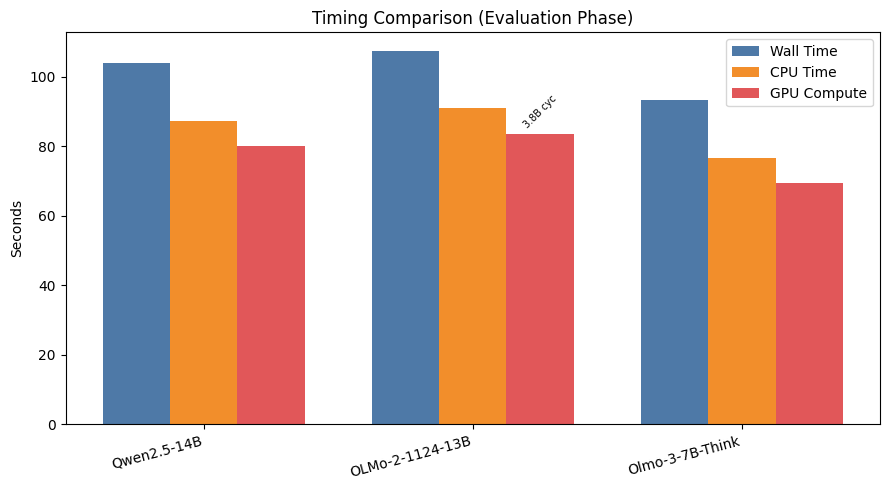

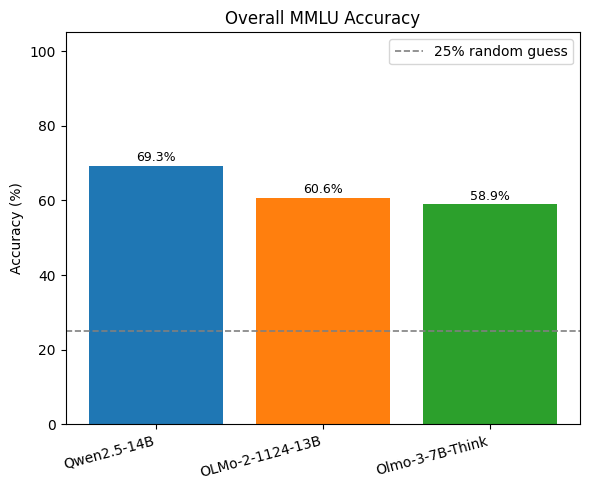

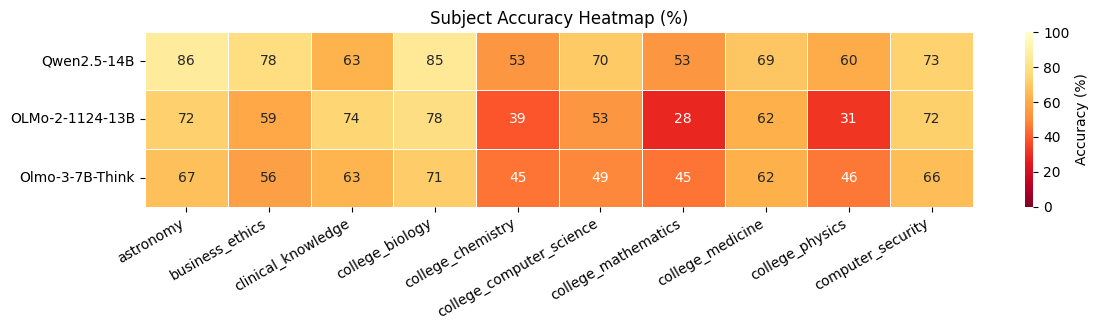

/tmp/ipython-input-3973855367.py:209: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("RdYlGn", len(ordered_labels))


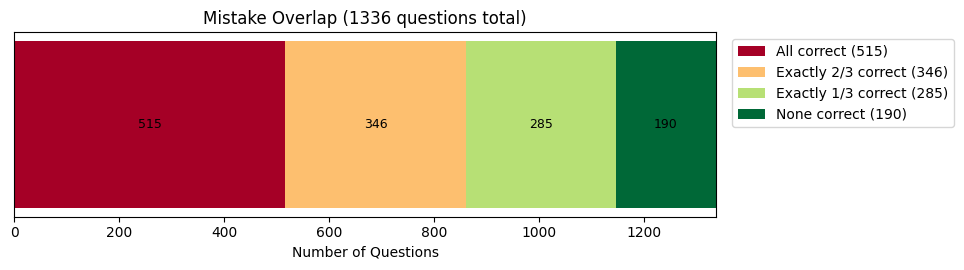

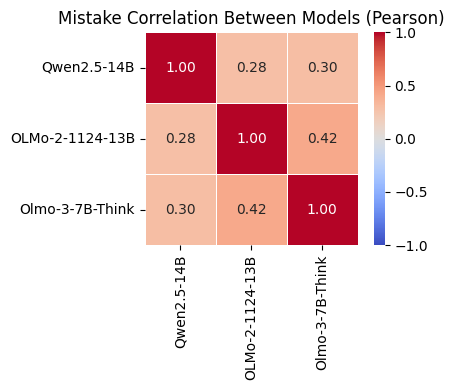


Mistake Correlation Interpretation:
  Qwen2.5-14B ↔ OLMo-2-1124-13B: r=0.28  → moderate similarity
  Qwen2.5-14B ↔ Olmo-3-7B-Think: r=0.30  → moderate similarity
  OLMo-2-1124-13B ↔ Olmo-3-7B-Think: r=0.42  → moderate similarity

✅ All visualizations complete!


In [111]:
# ── Inline Visualization (Step 5) ─────────────────────────────────────────────
# Reads directly from `all_model_results` in memory — no JSON export needed.

import subprocess, sys

def _ensure(pkg, import_name=None):
    import importlib
    name = import_name or pkg
    try:
        importlib.import_module(name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

_ensure("matplotlib")
_ensure("seaborn")
_ensure("pandas")
_ensure("numpy")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np
import os

# ── Helpers ────────────────────────────────────────────────────────────────────

def _display_name(model_path):
    """Convert a HF model path to a short display name."""
    base = model_path.split("/")[-1]
    # Drop trailing '-Instruct', '-it', '-v2' suffixes for brevity
    for suffix in ["-Instruct", "-instruct", "-it", "-v2"]:
        if base.endswith(suffix):
            base = base[:-len(suffix)]
            break
    return base


def _build_timing_df(results):
    rows = []
    for model_path, data in results.items():
        timing = data["timing"]
        eval_phase = timing["phases"].get("evaluation", {})
        inf = timing.get("inference", {})
        cm = timing.get("cuda_metrics", {})

        wall_time  = eval_phase.get("wall_time", 0)
        cpu_time   = eval_phase.get("total_cpu_time", 0)
        gpu_time   = inf.get("total", 0)          # CUDA event sum
        gpu_cycles = cm.get("gpu_cycles", {}).get("total_approx", 0)

        rows.append({
            "Model"      : _display_name(model_path),
            "Wall Time"  : wall_time,
            "CPU Time"   : cpu_time,
            "GPU Compute": gpu_time,
            "GPU Cycles" : gpu_cycles,
        })
    return pd.DataFrame(rows).set_index("Model")


def _build_accuracy_df(results):
    rows = []
    for model_path, data in results.items():
        rows.append({
            "Model"   : _display_name(model_path),
            "Accuracy": data["accuracy"],
        })
    return pd.DataFrame(rows).set_index("Model")


def _build_subject_heatmap_df(results):
    """Models × subjects accuracy matrix."""
    models = [_display_name(p) for p in results]
    all_subjects = MMLU_SUBJECTS
    data_matrix = []
    for model_path, data in results.items():
        subj_acc = {r["subject"]: r["accuracy"] for r in data["results"]}
        data_matrix.append([subj_acc.get(s, float("nan")) for s in all_subjects])
    df = pd.DataFrame(data_matrix, index=models, columns=all_subjects)
    return df


def _build_correctness_matrix(results):
    """Boolean matrix: model × question (True = correct)."""
    # Flatten all questions per model in subject order
    model_correct = {}
    for model_path, data in results.items():
        name = _display_name(model_path)
        flags = []
        for subj_result in data["results"]:
            for q in subj_result["questions"]:
                flags.append(q["is_correct"])
        model_correct[name] = flags

    df = pd.DataFrame(model_correct)
    return df  # rows = questions, cols = models


SAVE_DIR = "visualizations"
SAVE_PLOTS = False   # Set True to write PNGs to visualizations/


def _maybe_save(fig, filename):
    if SAVE_PLOTS:
        os.makedirs(SAVE_DIR, exist_ok=True)
        path = os.path.join(SAVE_DIR, filename)
        fig.savefig(path, bbox_inches="tight", dpi=150)
        print(f"  Saved: {path}")


# ── Guard ──────────────────────────────────────────────────────────────────────
if "all_model_results" not in dir() or not all_model_results:
    print("⚠️  `all_model_results` is empty — run the main() cell first.")
else:
    print(f"Visualizing {len(all_model_results)} model(s): "
          + ", ".join(_display_name(m) for m in all_model_results))

    timing_df  = _build_timing_df(all_model_results)
    acc_df     = _build_accuracy_df(all_model_results)
    subj_df    = _build_subject_heatmap_df(all_model_results)
    correct_df = _build_correctness_matrix(all_model_results)

    models = list(acc_df.index)
    n = len(models)
    palette = sns.color_palette("tab10", n)

    # ── Plot 1: Timing Comparison ──────────────────────────────────────────────
    fig1, ax1 = plt.subplots(figsize=(max(8, n * 3), 5))
    time_cols = ["Wall Time", "CPU Time", "GPU Compute"]
    x = np.arange(n)
    width = 0.25
    colors = ["#4e79a7", "#f28e2b", "#e15759"]

    for j, (col, color) in enumerate(zip(time_cols, colors)):
        vals = [timing_df.loc[m, col] if m in timing_df.index else 0 for m in models]
        bars = ax1.bar(x + j * width, vals, width, label=col, color=color)
        # Annotate GPU Compute bars with GPU cycles
        if col == "GPU Compute":
            for bar, m in zip(bars, models):
                cycles = timing_df.loc[m, "GPU Cycles"] if m in timing_df.index else 0
                if cycles > 0:
                    ax1.text(bar.get_x() + bar.get_width() / 2,
                             bar.get_height() + 1,
                             f"{cycles/1e9:.1f}B cyc",
                             ha="center", va="bottom", fontsize=7, rotation=45)

    ax1.set_xticks(x + width)
    ax1.set_xticklabels(models, rotation=15, ha="right")
    ax1.set_ylabel("Seconds")
    ax1.set_title("Timing Comparison (Evaluation Phase)")
    ax1.legend()
    plt.tight_layout()
    _maybe_save(fig1, "1_timing_comparison.png")
    plt.show()

    # ── Plot 2: Overall Accuracy ───────────────────────────────────────────────
    fig2, ax2 = plt.subplots(figsize=(max(6, n * 2), 5))
    accs = [acc_df.loc[m, "Accuracy"] for m in models]
    bars2 = ax2.bar(models, accs, color=palette)
    ax2.axhline(25, linestyle="--", color="gray", linewidth=1.2, label="25% random guess")
    for bar, acc in zip(bars2, accs):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f"{acc:.1f}%", ha="center", va="bottom", fontsize=9)
    ax2.set_ylabel("Accuracy (%)")
    ax2.set_ylim(0, 105)
    ax2.set_title("Overall MMLU Accuracy")
    ax2.legend()
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    _maybe_save(fig2, "2_overall_accuracy.png")
    plt.show()

    # ── Plot 3: Subject Accuracy Heatmap ──────────────────────────────────────
    if not subj_df.empty:
        fig3, ax3 = plt.subplots(figsize=(max(10, len(MMLU_SUBJECTS) * 1.2),
                                          max(3, n * 0.8 + 1)))
        sns.heatmap(subj_df, annot=True, fmt=".0f", cmap="YlOrRd_r",
                    vmin=0, vmax=100, ax=ax3,
                    linewidths=0.5, cbar_kws={"label": "Accuracy (%)"})
        ax3.set_title("Subject Accuracy Heatmap (%)")
        ax3.set_xlabel("")
        ax3.set_ylabel("")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        _maybe_save(fig3, "3_subject_heatmap.png")
        plt.show()

    # ── Plot 4: Mistake Overlap ────────────────────────────────────────────────
    if not correct_df.empty and n > 1:
        total_q = len(correct_df)
        # Count how many models answered each question correctly
        correct_counts = correct_df.sum(axis=1)  # 0 … n

        buckets = {}
        buckets["All correct"]  = int((correct_counts == n).sum())
        buckets["None correct"] = int((correct_counts == 0).sum())
        for k in range(1, n):
            label = f"Exactly {k}/{n} correct"
            buckets[label] = int((correct_counts == k).sum())

        # Sort: all correct → partial → none correct
        ordered_labels = (["All correct"]
                          + [f"Exactly {k}/{n} correct" for k in range(n - 1, 0, -1)]
                          + ["None correct"])
        ordered_vals = [buckets[l] for l in ordered_labels]

        cmap = plt.cm.get_cmap("RdYlGn", len(ordered_labels))
        colors4 = [cmap(i) for i in range(len(ordered_labels))]

        fig4, ax4 = plt.subplots(figsize=(10, max(2, n * 0.6 + 1)))
        left = 0
        for label, val, color in zip(ordered_labels, ordered_vals, colors4):
            if val > 0:
                bar = ax4.barh(0, val, left=left, color=color, label=f"{label} ({val})")
                ax4.text(left + val / 2, 0, str(val),
                         ha="center", va="center", fontsize=9, color="black")
                left += val

        ax4.set_xlim(0, total_q)
        ax4.set_yticks([])
        ax4.set_xlabel("Number of Questions")
        ax4.set_title(f"Mistake Overlap ({total_q} questions total)")
        ax4.legend(loc="upper right", bbox_to_anchor=(1.35, 1))
        plt.tight_layout()
        _maybe_save(fig4, "4_mistake_overlap.png")
        plt.show()

    elif not correct_df.empty and n == 1:
        # Single model — just show correct vs incorrect
        total_q = len(correct_df)
        n_correct = int(correct_df.iloc[:, 0].sum())
        n_wrong   = total_q - n_correct
        fig4, ax4 = plt.subplots(figsize=(8, 2))
        ax4.barh(0, n_correct, color="#59a14f", label=f"Correct ({n_correct})")
        ax4.barh(0, n_wrong,   left=n_correct, color="#e15759", label=f"Incorrect ({n_wrong})")
        ax4.set_xlim(0, total_q)
        ax4.set_yticks([])
        ax4.set_xlabel("Number of Questions")
        ax4.set_title(f"Correct vs Incorrect ({models[0]})")
        ax4.legend(loc="upper right")
        plt.tight_layout()
        _maybe_save(fig4, "4_correct_vs_incorrect.png")
        plt.show()

    # ── Plot 5: Mistake Correlation Heatmap ────────────────────────────────────
    if not correct_df.empty and n > 1:
        corr = correct_df.astype(float).corr(method="pearson")

        fig5, ax5 = plt.subplots(figsize=(max(5, n + 1), max(4, n)))
        mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # show lower triangle + diag
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
                    vmin=-1, vmax=1, ax=ax5,
                    linewidths=0.5, square=True)
        ax5.set_title("Mistake Correlation Between Models (Pearson)")
        plt.tight_layout()
        _maybe_save(fig5, "5_mistake_correlation.png")
        plt.show()

        # Interpretation
        print("\nMistake Correlation Interpretation:")
        for i in range(n):
            for j in range(i + 1, n):
                r = corr.iloc[i, j]
                if r > 0.8:
                    interp = "very similar error patterns"
                elif r > 0.5:
                    interp = "similar error patterns"
                elif r > 0.2:
                    interp = "moderate similarity"
                elif r > -0.2:
                    interp = "little correlation"
                else:
                    interp = "complementary (different errors)"
                print(f"  {corr.index[i]} ↔ {corr.columns[j]}: r={r:.2f}  → {interp}")

    print("\n✅ All visualizations complete!")


## Download Results File

The results JSON file is saved to the current directory. Download it using one of the methods below.

In [99]:
# Download results file
print("="*70)
print("DOWNLOAD RESULTS FILE")
print("="*70)

# Find the most recent results file
result_files = sorted(glob.glob("mmlu_multi_model_results_*.json"))

if not result_files:
    print("⚠️  No results files found")
else:
    latest_file = result_files[-1]
    file_size = os.path.getsize(latest_file) / 1024  # KB
    print(f"✓ Results file: {latest_file}")
    print(f"  File size: {file_size:.1f} KB")
    print()

    # Try to download via google.colab.files (regular Colab UI)
    try:
        from google.colab import files
        files.download(latest_file)
        print("✓ Download started via browser!")
    except ImportError:
        # VSCode Colab extension detected
        print("⚠️  VSCode Colab Extension Detected")
        print()
        print("To download via VSCode:")
        print("  1. Click the 'Files' icon in the left sidebar (or press Ctrl+Shift+E)")
        print(f"  2. Navigate to the current directory")
        print(f"  3. Right-click on: {os.path.basename(latest_file)}")
        print("  4. Select 'Download'")
        print()
        print(f"Full path: {os.path.abspath(latest_file)}")

print("="*70)

DOWNLOAD RESULTS FILE
⚠️  No results files found
